# 49. The Equal Interval Interpolation Formulas

**Part 7: Interpolation**

## Learning objectives

By the end of this lesson you will be able to:

1. Derive **Gregory-Newton forward and backward** from lesson 48's operator algebra.
2. Derive the **Gauss central** formulas, and say why there are two of them.
3. State **Stirling**, **Bessel**, **Everett** and **Steffensen**, and say what each reads from
   the table.
4. Verify that all eight are **the same polynomial**, and find where that stops being true.
5. Say which formula to use where, for the right reason rather than the traditional one.
6. Explain why these formulas were worth naming, and what has replaced them.

## Prerequisites

Lesson 48 (the operator algebra, which every formula here is a rearrangement inside). Lesson 44
(the Newton form and barycentric evaluation, used as the reference). Lesson 45 (divided
differences, and the accuracy limit that caps every formula here).

---

## 1. Where they come from

Write $s = (t - x_0)/h$, so $t = x_0 + sh$ and $s$ counts grid steps. Then, as operators,

$$
p(t) = E^s f_0 = (1 + \Delta)^s f_0 = \sum_k \binom{s}{k}\Delta^k f_0
$$

using the binomial series, with $\binom{s}{k} = s(s-1)\cdots(s-k+1)/k!$ extended to real $s$.

**That is the Gregory-Newton forward formula, derived in one line.** No argument about
interpolation was needed at all: it is the binomial theorem applied to $E = 1 + \Delta$.

Doing the same with $\nabla$, $\delta$ and $\mu$, and choosing where to centre, gives every other
formula in this lesson. They differ only in which corner of the difference table they read.

In [1]:
# Standard setup, the same in every lesson of this course.
import sys, pathlib

_root = pathlib.Path.cwd()
while not (_root / "src" / "nalib").is_dir() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root / "src"))

import numpy as np
import matplotlib.pyplot as plt

SEED = 42                                  # fixed so your numbers match the text
rng = np.random.default_rng(SEED)

np.set_printoptions(precision=6, linewidth=100, suppress=False)
plt.rcParams.update({
    "figure.figsize": (7.5, 4.5), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 10,
})

In [2]:
from nalib import equalinterval as ei

print("the generalised binomial C(s, k), which is what makes s real:")
orders = np.arange(5)
print(f"{'s':>7}" + "".join(f"{'k=' + str(k):>12}" for k in orders))
for s in (0.0, 0.5, 1.0, 1.5, 2.0, 2.5, -0.5):
    row = [float(ei.binomial_s(s, int(k))) for k in orders]
    print(f"{s:>7.1f}" + "".join(f"{v:>12.5f}" for v in row))
print()
print("C(s, k) vanishes at s = 0, 1, ..., k-1, which is what makes every")
print("formula reproduce the data at the nodes")

the generalised binomial C(s, k), which is what makes s real:
      s         k=0         k=1         k=2         k=3         k=4
    0.0     1.00000     0.00000    -0.00000     0.00000    -0.00000
    0.5     1.00000     0.50000    -0.12500     0.06250    -0.03906
    1.0     1.00000     1.00000     0.00000    -0.00000     0.00000
    1.5     1.00000     1.50000     0.37500    -0.06250     0.02344
    2.0     1.00000     2.00000     1.00000     0.00000    -0.00000
    2.5     1.00000     2.50000     1.87500     0.31250    -0.03906
   -0.5     1.00000    -0.50000     0.37500    -0.31250     0.27344

C(s, k) vanishes at s = 0, 1, ..., k-1, which is what makes every
formula reproduce the data at the nodes


## 2. The two diagonal formulas

**Gregory-Newton forward** reads the top diagonal of the table:

$$
p(x_0 + sh) = \sum_k \binom{s}{k}\Delta^k f_0
$$

**Gregory-Newton backward** reads the bottom diagonal, with $s$ measured from the last node:

$$
p(x_n + sh) = \sum_k \binom{s+k-1}{k}\nabla^k f_n
$$

In [3]:
from nalib import interp as ip

nodes = np.linspace(0.0, 1.0, 9)
values = np.exp(2.0 * nodes)

print("both diagonal formulas against the true interpolating polynomial:")
print(f"{'t':>7}{'forward':>16}{'backward':>16}{'barycentric':>16}{'largest gap':>15}")
for t in (0.06, 0.25, 0.5, 0.75, 0.94):
    f = float(np.atleast_1d(ei.gregory_newton_forward(nodes, values, t))[0])
    b = float(np.atleast_1d(ei.gregory_newton_backward(nodes, values, t))[0])
    r = float(ip.evaluate_barycentric(nodes, values, t))
    print(f"{t:>7.2f}{f:>16.10f}{b:>16.10f}{r:>16.10f}{max(abs(f - r), abs(b - r)):>15.2e}")
    assert max(abs(f - r), abs(b - r)) < 1e-9 * max(abs(r), 1.0)

both diagonal formulas against the true interpolating polynomial:
      t         forward        backward     barycentric    largest gap
   0.06    1.1274967416    1.1274967416    1.1274967416       2.44e-15
   0.25    1.6487212707    1.6487212707    1.6487212707       0.00e+00
   0.50    2.7182818285    2.7182818285    2.7182818285       0.00e+00
   0.75    4.4816890703    4.4816890703    4.4816890703       8.88e-16
   0.94    6.5535049933    6.5535049933    6.5535049933       8.88e-16


They agree with each other and with lesson 44's barycentric evaluation to $10^{-15}$ everywhere.
They are the same polynomial, read from opposite ends.

## 3. The central formulas, and why two

A **central** formula expands about a node in the middle and takes differences alternately below
and above it, zig-zagging along the central diagonal.

Going **down then up** gives Gauss forward:

$$
p = f_0 + s\,\delta f_{1/2} + \binom{s}{2}\delta^2 f_0 + \binom{s+1}{3}\delta^3 f_{1/2} + \cdots
$$

Going **up then down** gives Gauss backward:

$$
p = f_0 + s\,\delta f_{-1/2} + \binom{s+1}{2}\delta^2 f_0 + \binom{s+1}{3}\delta^3 f_{-1/2} + \cdots
$$

There are two because an odd central difference lands on a **half point**, and there are two half
points adjacent to any node. That is lesson 48's offset, showing up as a fork in the road.

**Stirling** takes the average of the two, so it is symmetric about the node. **Bessel** takes the
average about the **midpoint** between two nodes instead, which is the natural thing when
interpolating halfway between tabulated values, the commonest use of a printed table.

**Everett** keeps only the **even** order differences, using two central nodes, so half the table
is never needed. That mattered enormously when tables were printed and paper was the cost.
**Steffensen** is the dual arrangement bringing the odd differences in.

In [4]:
print("all eight formulas at the centre of a nine node table:")
out = ei.all_formulas_agree(nodes, values, 0.5)
for name, value in out["values"].items():
    print(f"  {name:>26}: {value:.14f}")
print()
print(f"  spread across all eight: {out['spread']:.2e}")
print(f"  central formulas reach full degree: {out['central_formulas_reach_full_degree']}")
assert out["central_formulas_reach_full_degree"]
assert out["relative_spread"] < 1e-12

all eight formulas at the centre of a nine node table:
      gregory-newton forward: 2.71828182845905
     gregory-newton backward: 2.71828182845905
               gauss forward: 2.71828182845905
              gauss backward: 2.71828182845905
                    stirling: 2.71828182845905
                      bessel: 2.71828182845905
                     everett: 2.71828182845905
                  steffensen: 2.71828182845905

  spread across all eight: 0.00e+00
  central formulas reach full degree: True


**Eight formulas, one number, to the last bit.** They are rearrangements, not alternatives.

## 4. Where that stops being true

Now the same comparison away from the centre.

In [5]:
print(f"{'t':>7}{'centre node':>13}{'room below':>12}{'room above':>12}"
      f"{'usable order':>14}{'spread':>12}{'diagonal spread':>18}")
for t in (0.06, 0.25, 0.5, 0.75, 0.94):
    out = ei.all_formulas_agree(nodes, values, t)
    c = int(np.argmin(np.abs(nodes - t)))
    print(f"{t:>7.2f}{c:>13}{c:>12}{nodes.size - 1 - c:>12}"
          f"{out['central_order_available']:>14}{out['spread']:>12.2e}"
          f"{out['diagonal_spread']:>18.2e}")
    assert out["diagonal_spread"] < 1e-10
    assert out["central_order_available"] == 2 * min(c, nodes.size - 1 - c)

      t  centre node  room below  room above  usable order      spread   diagonal spread
   0.06            0           0           8             0    1.36e-01          1.33e-15
   0.25            2           2           6             4    0.00e+00          0.00e+00
   0.50            4           4           4             8    0.00e+00          0.00e+00
   0.75            6           6           2             4    8.88e-16          8.88e-16
   0.94            8           8           0             0    8.36e-01          0.00e+00


Two columns tell the story.

**The diagonal spread is $10^{-15}$ everywhere.** Gregory-Newton forward and backward always reach
full degree, because a diagonal runs the whole length of the table.

**The overall spread is large at the ends**, because a central formula needs differences on both
sides of its node and there simply are none. At $t = 0.94$ the nearest node is the last one, and a
central expansion about it can reach order 0.

In [6]:
print("what each formula actually achieves at t = 0.94:")
truth = float(np.exp(2.0 * 0.94))
out = ei.all_formulas_agree(nodes, values, 0.94)
for name, value in sorted(out["values"].items(), key=lambda kv: abs(kv[1] - truth)):
    print(f"  {name:>26}: error {abs(value - truth):.4e}")

what each formula actually achieves at t = 0.94:
      gregory-newton forward: error 1.3107e-07
     gregory-newton backward: error 1.3107e-07
                  steffensen: error 5.8934e-03
                      bessel: error 2.8454e-02
                     everett: error 2.8754e-02
              gauss backward: error 5.1014e-02
                    stirling: error 4.4328e-01
               gauss forward: error 8.3555e-01


Gregory-Newton backward errs by $10^{-7}$, which is the interpolation error of the degree 8
polynomial and not a defect of the formula at all. The central formulas err by $10^{-1}$, because
they are computing a much lower degree polynomial.

**So the classical advice is not primarily about how fast the terms shrink.** It is that near the
ends the central formulas cannot be formed, and near the middle they can, and are then better
centred on the point of interest. Both families exist because neither covers the whole table.

## 5. The rule

In [7]:
print(f"{'s (grid steps from the start)':>32}  formula")
print(f"{'-' * 32}  {'-' * 26}")
n_nodes = 9
for s in (0.3, 0.9, 2.4, 4.0, 4.5, 6.1, 7.6, 8.2):
    print(f"{s:>32.1f}  {ei.best_formula_for(s, n_nodes)}")

   s (grid steps from the start)  formula
--------------------------------  --------------------------
                             0.3  gregory-newton forward
                             0.9  gregory-newton forward
                             2.4  bessel
                             4.0  stirling
                             4.5  bessel
                             6.1  stirling
                             7.6  gregory-newton backward
                             8.2  gregory-newton backward


Near the start, forward. Near the end, backward. Near a node in the middle, Stirling, whose terms
are symmetric so the odd order contributions cancel. Near a midpoint, Bessel, which is centred
there.

At a **fixed truncation order**, which is the only regime where the choice has content, the
advice can be tested:

In [8]:
report = ei.error_by_position(np.exp, 11, 0.0, 1.0, order=4, n_probe=11)
print(f"{'s':>7}{'best formula at that point':>30}")
for s, name in report.best_at.items():
    print(f"{s:>7.2f}{name:>30}")

      s    best formula at that point
   0.00        gregory-newton forward
   1.00        gregory-newton forward
   2.00                       everett
   3.00                       everett
   4.00                       everett
   5.00                 gauss forward
   6.00                        bessel
   7.00                       everett
   8.00                        bessel
   9.00       gregory-newton backward
  10.00       gregory-newton backward


## 6. Everett and Steffensen are duals

Everett needs the even columns, Steffensen the odd ones. Between them they use every entry of the
table exactly once, and a table printed for one is useless for the other.

In [9]:
print(f"{'n':>4}{'t':>7}{'Everett error':>17}{'Steffensen error':>19}{'winner':>13}")
for n in (9, 13):
    x = np.linspace(0.0, 1.0, n)
    y = np.exp(2.0 * x)
    for t in (0.32, 0.5, 0.68):
        ref = float(ip.evaluate_barycentric(x, y, t))
        e = abs(float(np.atleast_1d(ei.everett(x, y, t))[0]) - ref)
        s = abs(float(np.atleast_1d(ei.steffensen(x, y, t))[0]) - ref)
        winner = "equal" if e == s else ("Everett" if e < s else "Steffensen")
        print(f"{n:>4}{t:>7.2f}{e:>17.3e}{s:>19.3e}{winner:>13}")
        assert (e == s) if abs(t - 0.5) < 1e-12 else True

   n      t    Everett error   Steffensen error       winner
   9   0.32        9.425e-07          2.225e-06      Everett
   9   0.50        0.000e+00          0.000e+00        equal
   9   0.68        2.550e-06          5.073e-07   Steffensen
  13   0.32        2.390e-10          5.723e-10      Everett
  13   0.50        0.000e+00          0.000e+00        equal
  13   0.68        6.511e-10          9.309e-11   Steffensen


At the centre they agree **exactly**, because both reach full degree there. Away from it they
truncate differently, and the asymmetry is systematic: Everett is better on the left of centre and
Steffensen on the right, because Steffensen's extra odd term is anchored at the right hand node.

Both are correct formulas, and which is more accurate depends on which side of the centre the
point sits. That is a real reason to keep both, not a defect in either.

## 7. What all of this is worth now

These formulas were designed for a specific job: a human, with a printed table of a function, a
pencil, and a point between two tabulated values. Everything about them is shaped by that. The
terms are ordered so the ones you can drop come last. Everett halves the printing cost. Bessel
puts the expansion where interpolation is actually wanted.

Almost none of that matters now. A computer evaluating a polynomial does not care which corner of
the table it reads, and lesson 44's barycentric form is faster than any of these and backward
stable besides.

What survives is worth naming precisely.

**The derivation technique.** Everything here came out of $E = 1 + \Delta$ and the binomial
series, and Part 9 will use exactly that machinery to derive every numerical differentiation and
integration formula.

**The central difference idea.** Symmetric formulas have their odd order error terms cancel, which
is why central differences are second order accurate where one sided ones are first order. That is
one of the most used facts in Parts 9, 10 and 11.

**The structural limit.** Section 4's table is a permanent fact about equally spaced data: near
the boundary you have less information, and no formula creates any. Every boundary condition in
every finite difference method for a differential equation is a version of that problem.

In [10]:
print("the accuracy ceiling all of these share, from lesson 45:")
from nalib import divdiff as dd
print(f"{'order':>7}{'relative spread across orderings':>36}")
for n in (5, 9, 12, 14):
    x = np.linspace(0.0, 1.0, n)
    out = dd.symmetry_report(x, np.exp(x), n_orders=20, rng=np.random.default_rng(7))
    print(f"{n - 1:>7}{out['relative_spread']:>36.2e}")
print()
print("no rearrangement of the table can beat that, because they all read the same table")

the accuracy ceiling all of these share, from lesson 45:
  order    relative spread across orderings
      4                            1.63e-13
      8                            1.38e-07
     11                            5.86e-02
     13                            1.91e+00

no rearrangement of the table can beat that, because they all read the same table


## 8. A picture

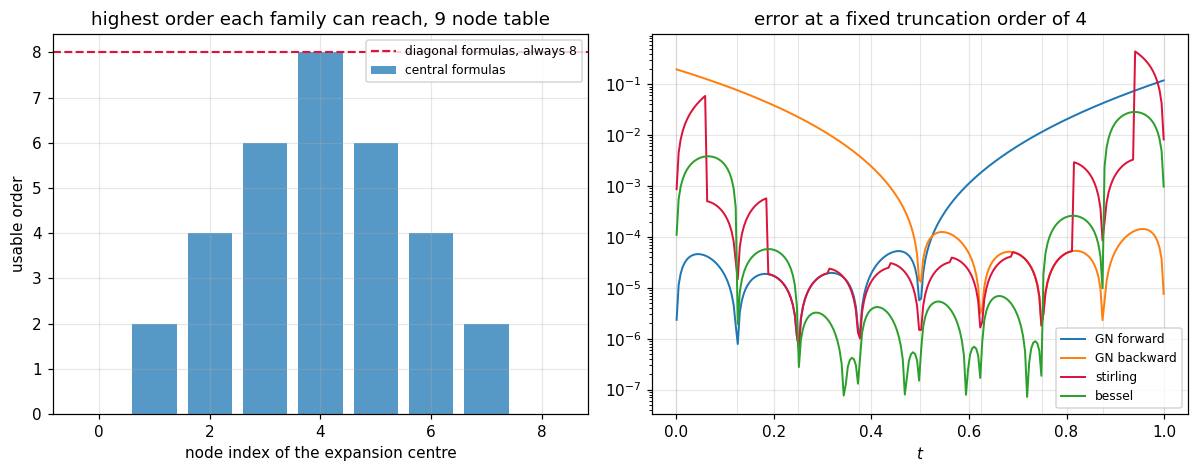

In [11]:
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(11, 4.4))

x9 = np.linspace(0.0, 1.0, 9)
y9 = np.exp(2.0 * x9)
avail = [ei.usable_central_order(x9, t) for t in x9]
ax_left.bar(np.arange(9), avail, color="tab:blue", alpha=0.75, label="central formulas")
ax_left.axhline(8, color="crimson", ls="--", lw=1.4, label="diagonal formulas, always 8")
ax_left.set_title("highest order each family can reach, 9 node table")
ax_left.set_xlabel("node index of the expansion centre")
ax_left.set_ylabel("usable order")
ax_left.legend(fontsize=8)

probe = np.linspace(0.001, 0.999, 240)
truth = np.exp(2.0 * probe)
for name, colour in (("gregory-newton forward", "tab:blue"),
                     ("gregory-newton backward", "tab:orange"),
                     ("stirling", "crimson"),
                     ("bessel", "tab:green")):
    got = np.asarray([float(np.atleast_1d(ei.FORMULAS[name](x9, y9, t, order=4))[0])
                      for t in probe])
    ax_right.semilogy(probe, np.abs(got - truth) + 1e-18, lw=1.3, color=colour,
                      label=name.replace("gregory-newton ", "GN "))
for node in x9:
    ax_right.axvline(node, color="0.9", lw=0.7, zorder=0)
ax_right.set_title("error at a fixed truncation order of 4")
ax_right.set_xlabel("$t$")
ax_right.legend(fontsize=8)

fig.tight_layout()
plt.show()

The left panel is section 4's structural fact, which is the real reason both families exist. The
right panel is the classical advice: at a fixed order, each formula is best in its own region, and
the regions are exactly where the tradition says they are.

## 9. Exercises

**Level 1, conceptual**

1.1 All eight formulas are the same polynomial. Say what is actually being chosen between, and
name the one situation in which the choice changes the answer.

1.2 There are two Gauss formulas rather than one. Explain what forces that, in terms of lesson
48's operators.

1.3 Everett's formula uses only the even difference columns. Say what that saved, for whom, and
whether it saves anything now.

**Level 2, mathematical**

2.1 Derive the Gregory-Newton forward formula from $E^s = (1 + \Delta)^s$, and state the
convergence condition on the binomial series.

2.2 Derive the Gregory-Newton backward formula, and show it is the forward formula with the table
read from the other end.

2.3 Derive both Gauss formulas from $E^s = (1 + \delta E^{1/2})^s$, and show that Stirling is
their average and Bessel is the average taken about the midpoint.

2.4 Derive Everett's formula from Bessel's by collecting and cancelling the odd terms, and count
how many table entries each needs.

2.5 Show that the error term of the Gregory-Newton forward formula truncated at order $m$ is
$\binom{s}{m+1} h^{m+1} f^{(m+1)}(\xi)$, and use it to justify the rule of section 5.

**Level 3, computational**

3.1 Implement **inverse interpolation**, solving $f(t) = c$ for $t$ by interpolating $t$ as a
function of $f$, and measure when it fails.

3.2 Implement **subtabulation**, filling in a table at a finer spacing from a coarse one, and
measure the error against direct evaluation.

3.3 Implement all eight formulas with a **fixed truncation order** and an automatic choice of
which to use, and measure the resulting error against always using one.

**Level 4, experimental**

4.1 Measure the error of each formula against position at several truncation orders, and determine
whether the classical regions are the right ones at every order.

4.2 Measure the largest order at which each formula still improves the answer, and relate it to
lesson 45's symmetry failure.

4.3 Measure the effect of a single rounding error in the table on each formula's output, and find
which formula is least sensitive.

**Level 5, advanced**

5.1 **Why central differences are second order.** Show that symmetric formulas have their odd
order error terms cancel, and identify every place in Parts 9 to 11 where that fact is used.

5.2 **The boundary problem is permanent.** Section 4 shows central formulas failing at the ends of
a table. Explain why every finite difference method for a boundary value problem meets the same
issue, and describe two standard responses.

5.3 **What replaced these formulas, and what did not.** Identify which jobs these formulas did
that are now done differently, which are now done by the same formulas under other names, and
which are simply not done at all any more.

## 10. Key takeaways

- **Every formula here is $E^s$ expanded a different way.** Gregory-Newton forward is the binomial
  theorem applied to $E = 1 + \Delta$, and the rest follow by changing which operator and which
  centre.

- **All eight are the same polynomial**, agreeing to the last bit at the centre of a nine node
  table.

- **They stop agreeing at the ends, and that is the real content.** A central formula needs
  differences on both sides, so at the first and last node it reaches order 0. At $t = 0.94$ of a
  nine node table the central formulas err by $10^{-1}$ and Gregory-Newton backward by $10^{-7}$,
  which is the interpolation error and not a defect.

- **The diagonal formulas always reach full degree**, because a diagonal runs the length of the
  table. That is why both families exist.

- **Everett and Steffensen are duals**: even columns and odd columns, agreeing exactly at the
  centre and truncating differently away from it, with Everett better left of centre and
  Steffensen right of it.

- **They were designed for a human with a printed table**, and most of what shaped them no longer
  applies. What survives is the derivation technique, the central difference idea, and the
  structural fact about boundaries.

- **All of them share lesson 45's ceiling.** They read the same difference table, so no
  rearrangement can beat the order at which the table itself stops carrying information.

## Where this goes next

Lessons 50 and 51 take the other route out of lesson 46 entirely: keep the degree at 1 or 3 and
add pieces. Part 9 reuses this lesson's operator derivations to produce every numerical
differentiation and integration formula. Parts 10 and 11 meet section 4's boundary problem again,
where it becomes the central difficulty rather than a footnote.